# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [13]:
# TODO
print("Số dòng: ", df.shape[0], "| Số cột: ", df.shape[1])
print("Tên cột: ", df.columns.tolist())
print()
df.info()

Số dòng:  1338 | Số cột:  7
Tên cột:  ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## A.2. Missing values & Duplicate data

In [25]:
# TODO
missing = df.isnull().sum()
missing[mising>0] if missing.sum()>0 else print("không có cột thiếu dữ liệu")

print("Số dòng trùng:", df.duplicated().sum())
df[df.duplicated(keep=False)] 
# .duplicated(keep=False) để lấy ra các dòng trùng

không có cột thiếu dữ liệu
Số dòng trùng: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


## A.3. Invalid values

In [32]:
# TODO
print("Giới tính: ", df['sex'].unique().tolist())
print("Tuổi<0: ", (df['age']<0).sum())
print("Khu vực: ", df['region'].unique())
print("Chi phí<0: ", (df['charges']<0).sum())

Giới tính:  ['female', 'male']
Tuổi<0:  0
Khu vực:  <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
Chi phí:  0


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [34]:
# TODO
# hàm phân loại bmi
def pl_bmi(bmi):
    if bmi<25:
        return "Nomal"
    elif bmi>=30:
        return "Obese"
    else:
        return "Overweight"


df['bmi_group'] = df['bmi'].apply(pl_bmi)
df

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Nomal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Obese
1334,18,female,31.920,0,no,northeast,2205.98080,Obese
1335,18,female,36.850,0,no,southeast,1629.83350,Obese
1336,21,female,25.800,0,no,southwest,2007.94500,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [37]:
# TODO
for col in ['age', 'bmi', 'charges']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_}, Median={median_}, Mode={mode_}")    

age: Mean=39.20702541106129, Median=39.0, Mode=18
bmi: Mean=30.66339686098655, Median=30.4, Mode=32.3
charges: Mean=13270.422265141257, Median=9382.033, Mode=1639.5631


## Group 2 — Dispersion

In [43]:
# TODO
for col in ['age', 'bmi', 'charges']:
    s = df[col]
    range_ = s.max() - s.min()
    q1, q3 = s.quantile([.25, .75]); iqr = q3-q1
    std_ = s.std()
    cv = s.std()/s.mean()*100
    print(f"---{col}---")
    print(f"range= {range_}, iqr= {iqr}, std= {std_}, cv= {cv}")

---age---
range= 46, iqr= 24.0, std= 14.049960379216154, cv= 35.8353132682499
---bmi---
range= 37.17, iqr= 8.3975, std= 6.098186911679014, cv= 19.88751259139792
---charges---
range= 62648.554110000005, iqr= 11899.625365, std= 12110.011236694001, cv= 91.25565859727446


## Group 3 — Location and Shape

---age---
skew= 0.05561008307259911, kurtosis= -1.2449206804584227
---bmi---
skew= 0.28372857291709386, kurtosis= -0.05502310583700032
---charges---
skew= 1.5141797118745743, kurtosis= 1.595821363956751


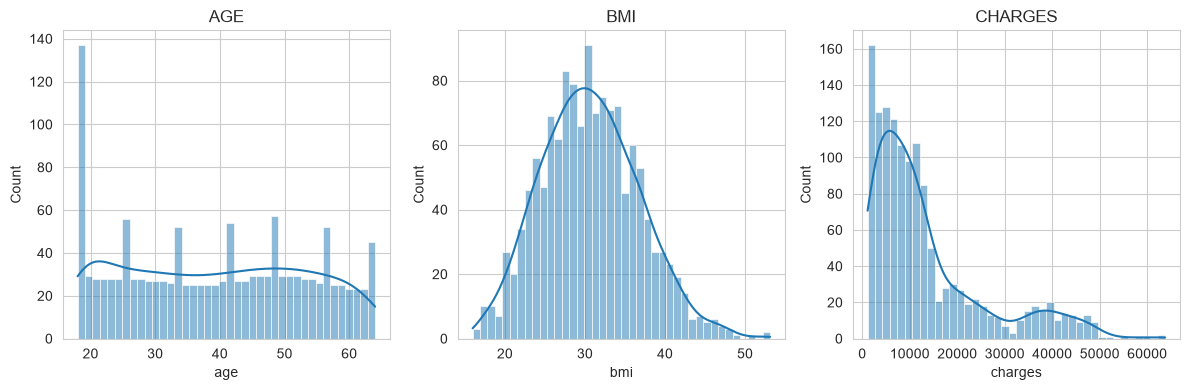

Nhận xét: age có skew gần 0 -> có phân phối gần đối xứng, kurtosis âm nên phân bố khá bẹt
BMI lệch phải nhẹ, kurtosis gần 0 cho thấy hình dạng phân phối tương đối chuẩn
Charges lệch trái và có khả năng xuất hiện giá trị cực đoan


In [52]:
# TODO
for col in ['age', 'bmi', 'charges']:
    s = df[col]
    skew_, kurtosis_ = stats.skew(s), stats.kurtosis(s)
    print(f"---{col}---")
    print(f"skew= {skew_}, kurtosis= {kurtosis_}")


fig, axes = plt.subplots(1,3,figsize=(12,4))
sns.histplot(df['age'], bins=40, kde=True, ax=axes[0]); axes[0].set_title('AGE')
sns.histplot(df['bmi'], bins=40, kde=True, ax=axes[1]); axes[1].set_title('BMI')
sns.histplot(df['charges'], bins=40, kde=True, ax=axes[2]); axes[2].set_title('CHARGES')
plt.tight_layout(); plt.show()

print("Nhận xét: age có skew gần 0 -> có phân phối gần đối xứng, kurtosis âm nên phân bố khá bẹt")
print("BMI lệch phải nhẹ, kurtosis gần 0 cho thấy hình dạng phân phối tương đối chuẩn")
print("Charges lệch trái và có khả năng xuất hiện giá trị cực đoan")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [98]:
# TODO
# .unstack() biến index thành cột
asm= df.groupby(['region', 'smoker'])['charges'].mean().unstack()
tl = asm['yes']/asm['no']
print(asm)
print()

print(f"Người hút thuốc trả chi phí chênh lệch với người k hút thuốc tương đối đồng đều giữa các vùng")
print(tl)
print(tl.mean())

smoker              no           yes
region                              
northeast  9165.531672  29673.536473
northwest  8556.463715  30192.003182
southeast  8032.216309  34844.996824
southwest  8019.284513  32269.063494

Người hút thuốc trả chi phí chênh lệch với người k hút thuốc tương đối đồng đều giữa các vùng
region
northeast    3.237514
northwest    3.528561
southeast    4.338155
southwest    4.023933
dtype: float64
3.78204062277295


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [99]:
# TODO
# .corr() tính độ tương quan
ys = df[df['smoker'] == 'yes']['bmi'].corr(df[df['smoker'] == 'yes']['charges'])
ns = df[df['smoker'] == 'no']['bmi'].corr(df[df['smoker'] == 'no']['charges'])
print("Có hút thuốc: ", ys.round(2))
print("Không hút thuốc: ", ns.round(2))
print("Nhận xét: BMI tương quan đến chi phí mạnh hơn ở nhóm hút thuốc")


Có hút thuốc:  0.81
Không hút thuốc:  0.08
Nhận xét: BMI tương quan đến chi phí mạnh hơn ở nhóm hút thuốc


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [82]:
# TODO
tb = df.groupby('region')['charges'].mean()
print("Vùng có chi phí bảo hiểm trung bình cao nhất: ", tb.idxmax(), "| Chi phí tb= ", tb.max())


Vùng có chi phí bảo hiểm trung bình cao nhất:  southeast | Chi phí tb=  14735.41143760989


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [89]:
# TODO
print(df.groupby('children')['charges'].mean().sort_index())
print("Nhận xét: không thể kết luận vì từ 0-3 con chi phí trung bình có xu hướng tăng, nhưng từ 3-5 con chi phí trung bình lại giảm")

children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64
Nhận xét: không thể kết luận vì từ 0-3 con chi phí trung bình có xu hướng tăng, nhưng từ 3-5 con chi phí trung bình lại giảm


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

In [91]:
# TODO
df['age'].corr(df['charges'])
print("Nhận xét: tuổi và chi phí bảo hiểm có tương quan nhưng khá yếu -> tuổi tăng thì chi phí bảo hiểm cũng tăng nhưng tăng ít")

Nhận xét: tuổi và chi phí bảo hiểm có tương quan nhưng khá yếu -> tuổi tăng thì chi phí bảo hiểm cũng tăng nhưng tăng ít


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

dữ liệu sạch, chỉ có một dòng trùng dữ liệu.
tuổi lớn nhất và nhỏ nhất cách nhau 46 đơn vị, tuổi trung bình là 39, dữ liệu biến động 35,8% xoay quanh mean.
bmi cao nhất và thấp nhất cách nhau 37 đơn vị, bmi trung bình là 30,6 , dữ liệu biến động 19,8% xoay quanh mean.
charges cao nhất và thấp nhát cách nhay 62648,55 đơn vị, charges trung bình là 13270.

đồ thị age phân đối gần đối xứng và phân bố khác bẹt.
đồ thị bmi lệch phải nhẹ, có hình dạng phân phối tương đối chuẩn.
đồ thị charges lệch trái và kurtosis cao -> có khả năng xuất hiện giá trị cực đoan.

người hút thuốc trả chi phí cao hơn trung bình 3.7 lần so với người k hút thuốc.
bmi tương quan đến chi phí mạnh hơn ở nhóm hút thuốc.
vùng có chi phí bảo hiểm trung bình cao nhất là southeast.
số lượng con cái từ 0-3 con chi phí trung bình có xu hướng tăng nhưng từ 3-5 con có xu hướng giảm.
tuổi có tương quan với chi phí bảo hiểm nhưng k nhiều, tuổi tăng thì chi phí bảo hiểm cũng tăng nhưng chỉ tăng ít.